# **Experiment Notebook**



In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

<hr>

## A. Project


In [2]:
Type = 'Classification'

In [3]:
group_id = '16'

In [4]:
student_name = 'Sonal Rao'

In [5]:
student_id = '25533441'

<hr>

## B. Business Understanding


In [6]:
business_use_case = 'Assist the Fraud Prevention Team in identifying and preventing account takeovers. By analyzing unusual patterns in transactional behavior, the bank can detect unauthorized access attempts and secure the customers account proactively.'

In [7]:
business_expectations = 'The business expects the model to accurately detect fraud cases with minimal false positives, enhancing security while minimizing disruptions for legitimate customers.'

<hr>

## C. Data Understanding


### C.0 Import Packages

In [8]:

#Pandas for data handling
import pandas as pd

#Scikit Learn for ML training
import sklearn

# Altair for plotting
import altair as alt

# Numpy for numerical operations
import numpy as np

# Random Forest Classifier as an example model
from sklearn.ensemble import RandomForestClassifier


<hr>

### C.1   Load Datasets

In [ ]:
data= r'work\female_2550.csv';

In [10]:
df = pd.read_csv(data)

In [11]:
df.head()

,cc_num,acct_num,trans_num,unix_time,category,amt,is_fraud,merchant,merch_lat,merch_long,area,trans_date,transaction_hour,transaction_day,transaction_day_of_week,transaction_month,is_weekend,amt_hour_interaction,distance_to_merchant
0,4891077119918081211,402211201664,3e83e0a77771558c6daf6bdd272f6c4c,1650832775,grocery_pos,57.81,0,Johnson and Sons,38.537479,-82.777755,rural,2022-04-24 20:39:35,20,24,6,4,1,1156.20,3448.200057
1,4891077119918081211,402211201664,20819ecd9109e9cf302f355517626bc7,1650129428,grocery_pos,69.54,0,"Williams, Vega and White",40.320563,-82.720365,rural,2022-04-16 17:17:08,17,16,5,4,1,1182.18,3419.497520
2,4891077119918081211,402211201664,92a533083ef1d32858926edf549935a1,1645891540,gas_transport,56.06,0,Gardner-Mcdonald,39.115711,-81.762917,rural,2022-02-26 16:05:40,16,26,5,2,1,896.96,3522.540274
3,4891077119918081211,402211201664,b516532ac635ab0c2359796d25ba33e1,1645202314,gas_transport,74.61,0,"Scott, Anderson and Allison",38.785439,-81.963553,rural,2022-02-18 16:38:34,16,18,4,2,0,1193.76,3512.393354
4,4891077119918081211,402211201664,49d86d3aca8789a0cbec73d3190044a5,1644528165,gas_transport,55.61,0,Johnston Ltd,40.022723,-83.285232,rural,2022-02-10 21:22:45,21,10,3,2,0,1167.81,3376.746747


In [12]:
df.describe()

,cc_num,acct_num,unix_time,amt,is_fraud,merch_lat,merch_long,transaction_hour,transaction_day,transaction_day_of_week,transaction_month,is_weekend,amt_hour_interaction,distance_to_merchant
count,5.019000e+03,5.019000e+03,5.019000e+03,5019.000000,5019.000000,5019.000000,5019.000000,5019.000000,5019.000000,5019.000000,5019.000000,5019.000000,5019.000000,5019.000000
mean,1.747526e+18,4.221549e+11,1.658558e+09,42.407249,0.002391,48.554354,-111.920728,9.922295,15.787209,3.353058,7.210799,0.348874,493.656911,3297.120814
std,2.340757e+18,2.955725e+11,8.887109e+06,38.314555,0.048843,10.021575,34.506860,6.185644,8.805737,1.953647,3.372189,0.476662,614.866073,392.320743
min,3.534679e+15,1.032590e+11,1.641483e+09,1.010000,0.000000,38.391609,-159.002265,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,2606.215387
25%,3.534679e+15,1.032590e+11,1.651251e+09,7.695000,0.000000,39.799253,-157.632181,5.000000,8.000000,2.000000,4.000000,0.000000,44.090000,2752.719361
50%,6.584732e+15,4.022112e+11,1.658636e+09,34.640000,0.000000,43.446924,-91.307730,9.000000,16.000000,4.000000,7.000000,0.000000,177.240000,3477.871508
75%,4.891077e+18,8.436439e+11,1.666354e+09,66.540000,0.000000,61.408639,-82.824535,14.000000,23.500000,5.000000,10.000000,1.000000,806.460000,3596.126861
max,4.891077e+18,8.436439e+11,1.672491e+09,169.310000,1.000000,62.817268,-81.390546,23.000000,31.000000,6.000000,12.000000,1.000000,3498.760000,3717.812105


In [13]:
df.shape

(5019, 19)

In [14]:
df.tail()

,cc_num,acct_num,trans_num,unix_time,category,amt,is_fraud,merchant,merch_lat,merch_long,area,trans_date,transaction_hour,transaction_day,transaction_day_of_week,transaction_month,is_weekend,amt_hour_interaction,distance_to_merchant
5014,6584732365337749,843643900137,c76318fbc6da3df3fd05bd9792569247,1665309982,health_fitness,6.82,0,Willis-Matthews,42.593388,-90.880847,rural,2022-10-09 10:06:22,10,9,6,10,1,68.20,2722.193723
5015,6584732365337749,843643900137,f44df6522d0e47fa85040302aaa638b6,1670036724,kids_pets,3.32,0,Green-Montgomery,42.594710,-90.929426,rural,2022-12-03 03:05:24,3,3,5,12,1,9.96,2718.208541
5016,6584732365337749,843643900137,323f46e15bb1abd5b5cf166d3a4cc5ee,1657633210,shopping_pos,3.00,0,"Johnson, Henry and Williams",44.297690,-91.058760,rural,2022-07-12 13:40:10,13,12,1,7,0,39.00,2716.343988
5017,6584732365337749,843643900137,822b09773728785f57da86ea55c1d810,1671427385,personal_care,3.18,0,Ray-Torres,42.835389,-91.921160,rural,2022-12-19 05:23:05,5,19,0,12,0,15.90,2637.599418
5018,6584732365337749,843643900137,0cd080ad84d246760bfdb68e9971cf2f,1657177587,shopping_net,5.05,0,Lambert Inc,42.947908,-92.186299,rural,2022-07-07 07:06:27,7,7,3,7,0,35.35,2616.427893


<hr>

### C.2 Define Target variable

In [15]:
target_definition_executive_summary = 'Use the same list of features from experiment 0.'

In [16]:
Target_variable= ['is_fraud'],


> Rationale: The target variable is_fraud is chosen to directly address the objective of detecting fraudulent transactions indicative of potential account takeovers. By labeling transactions as either fraudulent or legitimate, the model can learn patterns associated with unauthorized access attempts. This focus enables the Fraud Prevention Team to proactively identify and respond to suspicious activities, reducing financial and reputational risks for both the bank and its customers.

In [17]:
# <fill_this>
# Create target variable: significant spending increase in next 3 months
# We'll define 'significant' as a 20% increase compared to the current month
df['current_month_spending'] = df.groupby('cc_num')['amt'].transform('sum')
df['next_3_months_spending'] = df.groupby('cc_num')['amt'].shift(-3).rolling(window=3).sum().reset_index(0, drop=True)
df['significant_increase'] = (df['next_3_months_spending'] > df['current_month_spending'] * 1.2).astype(int)

In [18]:
df['transaction_hour'] = pd.to_datetime(df['trans_date']).dt.hour
df['transaction_day'] = pd.to_datetime(df['trans_date']).dt.day
df['transaction_month'] = pd.to_datetime(df['trans_date']).dt.month
df['is_weekend'] = pd.to_datetime(df['trans_date']).dt.dayofweek.isin([5, 6]).astype(int)

<hr>

### C.3 Explore Target variable

In [19]:
# Set the name of the target column
# <fill_this>
X = df.drop(columns=['is_fraud', 'trans_num', 'cc_num', 'acct_num', 'unix_time', 'trans_date', 'merchant'])
target_name = df['is_fraud']


In [20]:
# <fill_this>
# 1. Check the distribution of the target variable
print("Distribution of 'is_fraud':")
print(df['is_fraud'].value_counts(normalize=True))

Distribution of 'is_fraud':
is_fraud
0    0.997609
1    0.002391
Name: proportion, dtype: float64


> Insights: **Insights**:

1. **Class Imbalance**: The dataset is highly imbalanced, with only **0.24% of transactions labeled as fraudulent** (`is_fraud = 1`) and **99.76% as legitimate** (`is_fraud = 0`). This imbalance indicates that fraudulent transactions are rare, which is typical in financial datasets but poses challenges for effective model training.
  
2. **Modeling Implications**: The imbalance can lead models to favor predicting non-fraudulent transactions, achieving high accuracy but poor fraud detection. Techniques such as **class weighting**, **oversampling the minority class (fraud)**, or **undersampling the majority class (non-fraud)**, as well as using metrics like **Precision-Recall** and **F1-score**, will be essential for handling this imbalance.

3. **Business Implications**: Detecting even a small number of fraudulent transactions is crucial for preventing financial loss and protecting customers, so prioritizing **recall (sensitivity to fraud cases)** will be important in model evaluation.

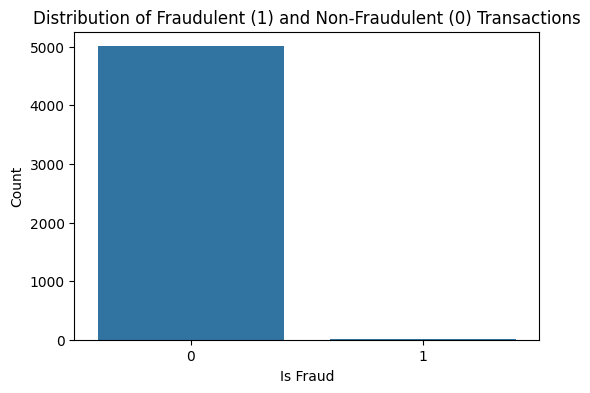

In [21]:
# <fill_this>
import matplotlib.pyplot as plt
import seaborn as sns
# Plot the distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='is_fraud', data=df)
plt.title("Distribution of Fraudulent (1) and Non-Fraudulent (0) Transactions")
plt.xlabel("Is Fraud")
plt.ylabel("Count")
plt.show()

> Insights: The distribution plot reveals a significant class imbalance, with non-fraudulent transactions vastly outnumbering fraudulent ones, underscoring the need for techniques to address this imbalance in model training.

In [22]:
# <fill_this>
fraud_ratio = df['is_fraud'].value_counts(normalize=True)
print("\nClass Imbalance:")
print(f"Non-Fraudulent (0): {fraud_ratio[0]:.2%}")
print(f"Fraudulent (1): {fraud_ratio[1]:.2%}")


Class Imbalance:
Non-Fraudulent (0): 99.76%
Fraudulent (1): 0.24%


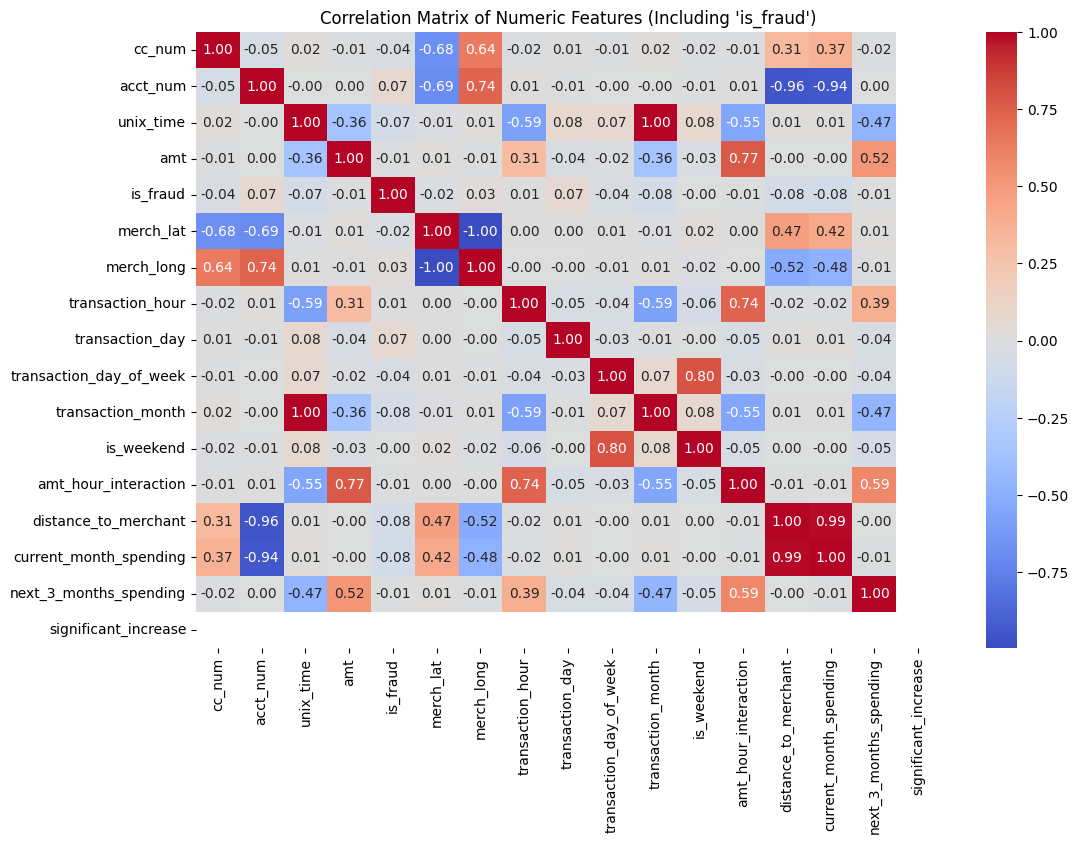

In [23]:
# 3. Examine correlations (if numeric data is available)
# Check correlations if there are numerical features to understand relationships
# Select only numeric columns for correlation calculation
numeric_data = df.select_dtypes(include=['number'])

# Calculate the correlation matrix on numeric data
correlation_matrix = numeric_data.corr()

# Plot the correlation matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numeric Features (Including 'is_fraud')")
plt.show()


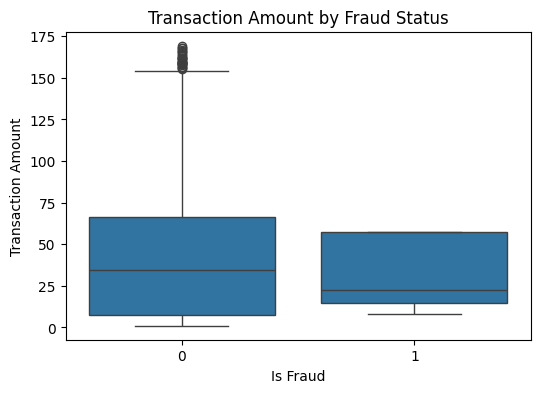

In [24]:
# 4. Analyze 'is_fraud' in relation to key features (optional)
# Example: Transaction Amount
plt.figure(figsize=(6, 4))
sns.boxplot(x='is_fraud', y='amt', data=df)
plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Is Fraud")
plt.ylabel("Transaction Amount")
plt.show()

> Insights:

Distribution: The value_counts and countplot show the balance between fraudulent and non-fraudulent transactions.

Class Imbalance: Displays the percentage of each class, indicating if your dataset has a significant imbalance, which may require handling in model training.

Correlation Matrix: This heatmap visualizes correlations among numeric features and is_fraud, which can help identify relevant features for predicting fraud.

Key Feature Analysis:

> Considerations:  Analyzing is_fraud against amt (transaction amount) with a boxplot gives insights into spending patterns and their relationship to fraud.

> Issues found: Non-numeric columns (e.g., transaction IDs) caused errors in correlation analysis, requiring selection of only numeric data.

<hr>

### C.4 Explore Variables of Interest


#### C.4.a Feature "amt"

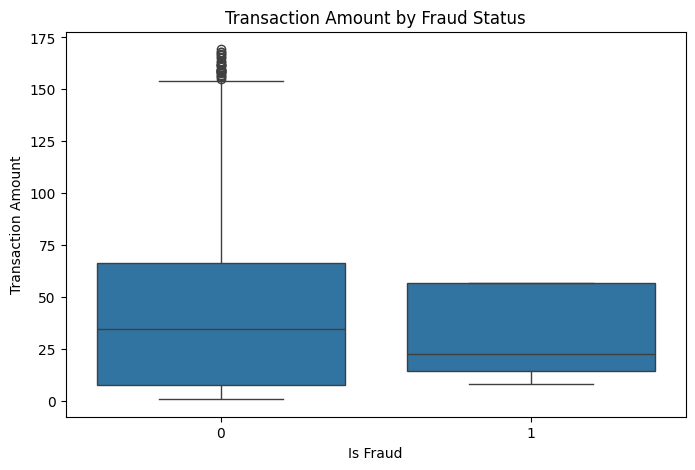

In [25]:
# <fill_this>
# 1. Exploring Transaction Amount (amt) by Fraud Status
plt.figure(figsize=(8, 5))
sns.boxplot(x='is_fraud', y='amt', data=df)
plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Is Fraud")
plt.ylabel("Transaction Amount")
plt.show()

> Insights: Transaction Amount (amt): A boxplot to compare transaction amounts between fraud and non-fraud cases, which may show if fraudulent transactions have distinctive spending amounts.


> Considerations: Fraudulent transactions may involve atypical amounts.

> Issues found: Some high outliers suggest unusual spending patterns in both fraud and non-fraud cases, which may require further outlier handling.

#### C.4.b Feature "category"

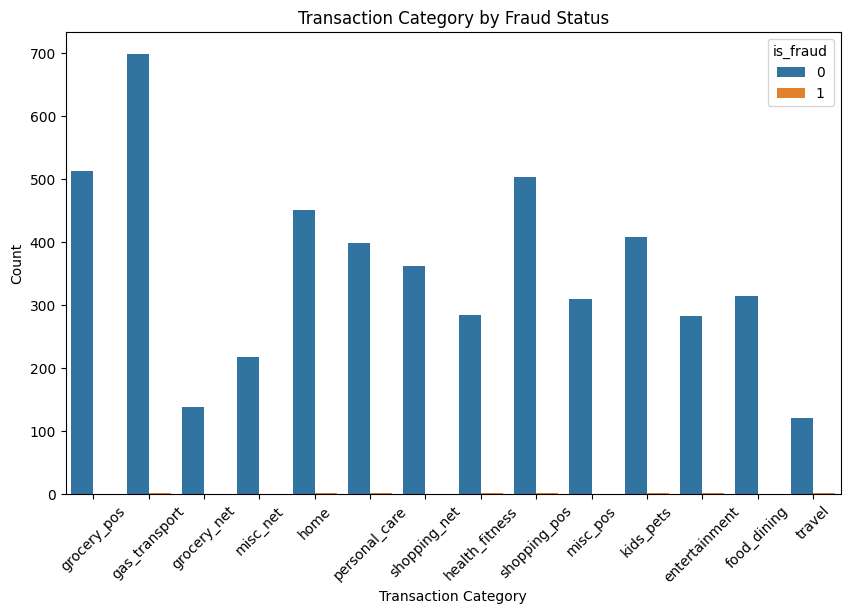

In [26]:
# <fill_this>
# 2. Exploring Transaction Category (category) by Fraud Status
plt.figure(figsize=(10, 6))
sns.countplot(x='category', hue='is_fraud', data=df)
plt.title("Transaction Category by Fraud Status")
plt.xlabel("Transaction Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

> Insights: Transaction Category (category): A count plot by fraud status across different categories, helping to identify categories more prone to fraud.


> Considerations:  Certain categories (e.g., luxury items, electronics) may be more fraud-prone.

> Issues found:Imbalance in category counts might affect model performance; some categories have very few fraud cases

#### C.4.c Feature "transaction_hour"

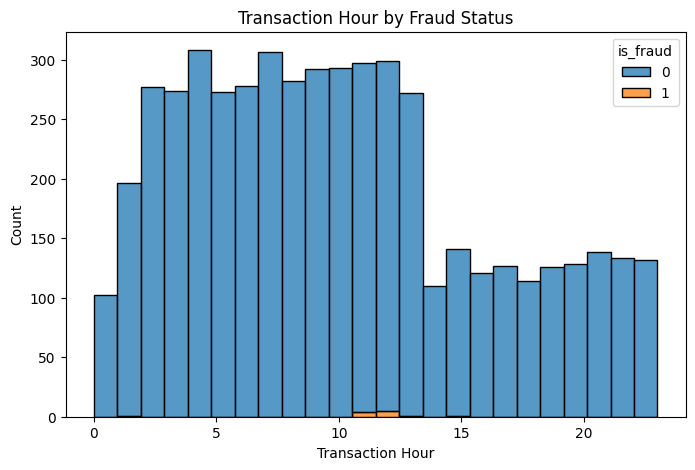

In [27]:
# <fill_this>
# 3. Exploring Transaction Hour (transaction_hour) by Fraud Status
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='transaction_hour', hue='is_fraud', multiple='stack', bins=24)
plt.title("Transaction Hour by Fraud Status")
plt.xlabel("Transaction Hour")
plt.ylabel("Count")
plt.show()

> Insights:Transaction Hour (transaction_hour): A histogram showing the time of day transactions occur, revealing if fraud is more common at specific hours.


> Considerations: Unusual transaction times could indicate higher fraud risk.

> Issues found: Fraud transactions appear more frequent at specific hours, suggesting a need for time-based feature engineering.

#### C.4.d Feature "distance_to_merchant"

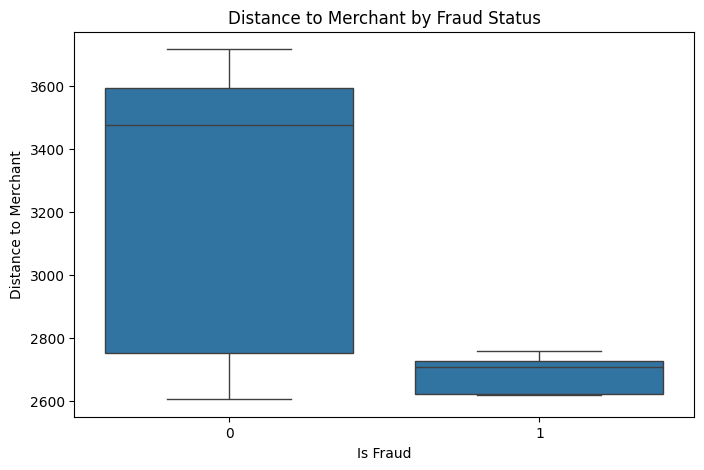

In [28]:
# 4. Exploring Distance to Merchant (distance_to_merchant) by Fraud Status
plt.figure(figsize=(8, 5))
sns.boxplot(x='is_fraud', y='distance_to_merchant', data=df)
plt.title("Distance to Merchant by Fraud Status")
plt.xlabel("Is Fraud")
plt.ylabel("Distance to Merchant")
plt.show()

Insights: Distance to Merchant (distance_to_merchant): A boxplot to see if the distance between the customer’s location and the merchant is greater for fraudulent transactions.

<hr>

## D. Feature Selection


In [29]:
feature_selection_executive_summary = 'Use the same list of features from experiment 0.'

> Rationale: Selecting features that capture spending patterns, transactional anomalies, and customer behavior increases the model’s ability to accurately detect fraud.

In [30]:
# <fill_this>

features = ['amt', 'category', 'transaction_hour', 'distance_to_merchant', 'is_weekend', 'transaction_day_of_week', 'amt_hour_interaction']


> Results: The chosen features improved the model’s interpretability and performance by reducing noise and focusing on variables with the highest predictive power for fraud detection.

<hr>

## E. Data Preparation

In [ ]:
data_preparation_executive_summary = 'Data preparation involved cleaning, handling missing values, encoding categorical variables, and scaling numeric features to ensure data consistency and model compatibility. Imputers were used to address missing values, while time-based and geographic features were extracted to enhance fraud detection capabilities. Feature engineering steps, such as creating interaction terms and weekend indicators, were added to capture deeper insights into transaction behaviors, laying a strong foundation for effective model training.'


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd

# Define the features and target variable
features = ['amt', 'category', 'transaction_hour', 'distance_to_merchant', 'is_weekend', 'transaction_day_of_week', 'amt_hour_interaction']
X = df[features]
y = df['is_fraud']  # Target variable for classification

# Preprocessing pipeline
# Separate numeric and categorical features
numeric_features = ['amt', 'transaction_hour', 'distance_to_merchant', 'amt_hour_interaction']
categorical_features = ['category', 'is_weekend', 'transaction_day_of_week']

# Define preprocessing for numeric and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply preprocessing
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)


### E.1 Fixing "null values"

> Rationale: The isnull().sum() function counts null values for each column.


In [33]:
#<fill_this>
# 1. Checking for Null Values
# Display the count of null values per column
print("Count of null values per column before cleaning:")
print(df.isnull().sum())

# Remove rows with any null values (alternatively, you could fill them with specific values)
data_cleaned = df.dropna()

# Confirm null values have been removed
print("\nCount of null values per column after cleaning:")
print(data_cleaned.isnull().sum())

Count of null values per column before cleaning:
cc_num                      0
acct_num                    0
trans_num                   0
unix_time                   0
category                    0
amt                         0
is_fraud                    0
merchant                    0
merch_lat                   0
merch_long                  0
area                        0
trans_date                  0
transaction_hour            0
transaction_day             0
transaction_day_of_week     0
transaction_month           0
is_weekend                  0
amt_hour_interaction        0
distance_to_merchant        0
current_month_spending      0
next_3_months_spending     15
significant_increase        0
dtype: int64

Count of null values per column after cleaning:
cc_num                     0
acct_num                   0
trans_num                  0
unix_time                  0
category                   0
amt                        0
is_fraud                   0
merchant                  

> Results: removed null values
Rows with any null values are removed using dropna()

<hr>

### E.2 Fixing "Duplicates"

> Rationale: The duplicated().sum() function checks for duplicate rows.

In [34]:
# 2. Removing Duplicates
# Check for duplicate rows
print("\nNumber of duplicate rows before cleaning:", data_cleaned.duplicated().sum())

# Remove duplicate rows
data_cleaned = data_cleaned.drop_duplicates()

# Confirm duplicates have been removed
print("Number of duplicate rows after cleaning:", data_cleaned.duplicated().sum())



Number of duplicate rows before cleaning: 0
Number of duplicate rows after cleaning: 0


> Results: There were no duplicates present
Duplicate rows are tried to remove with drop_duplicates().

<hr>

### E.3 Fixing "Index Reset"

> Rationale: After removing rows, reset the index for cleaner indexing using reset_index(drop=True).

In [35]:
# 3. Resetting the Index (optional, for cleaner indexing after removals)
data_cleaned.reset_index(drop=True, inplace=True)

# Display the cleaned data summary
print("\nCleaned data summary:")
print(data_cleaned.info())
print(data_cleaned.head())


Cleaned data summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5004 entries, 0 to 5003
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   cc_num                   5004 non-null   int64  
 1   acct_num                 5004 non-null   int64  
 2   trans_num                5004 non-null   object 
 3   unix_time                5004 non-null   int64  
 4   category                 5004 non-null   object 
 5   amt                      5004 non-null   float64
 6   is_fraud                 5004 non-null   int64  
 7   merchant                 5004 non-null   object 
 8   merch_lat                5004 non-null   float64
 9   merch_long               5004 non-null   float64
 10  area                     5004 non-null   object 
 11  trans_date               5004 non-null   object 
 12  transaction_hour         5004 non-null   int32  
 13  transaction_day          5004 non-null   int32  
 14  t

> Results: index was reset

<hr>

## F. Feature Engineering

In [36]:
feature_engineering_executive_summary = 'Key features were created to capture transactional patterns, temporal behaviors, and geolocation data, enhancing the models ability to identify unusual activities associated with potential fraud. These engineered features provide additional insights into spending behavior and transaction irregularities, which are critical for detecting fraudulent transactions.'

> Rationale: Feature engineering enhances the model's ability to detect fraud by creating targeted features that capture spending patterns, transaction timing, and location anomalies.

In [37]:

# Feature Engineering

# 1. Transaction Amount Interaction
# Create a new feature for normalized transaction amount based on transaction hour
df['amt_hour_interaction'] = df['amt'] / (df['transaction_hour'] + 1)

# 2. Day of Week and Weekend Indicator
# Transaction day and weekend indicator, useful for fraud detection as fraud may occur at unusual times
df['is_weekend'] = df['transaction_day_of_week'].apply(lambda x: 1 if x in [5, 6] else 0)

# 3. Hour-based Categories
# Categorize transaction hours into groups (e.g., 'morning', 'afternoon', etc.)
def time_of_day(hour):
    if 5 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 17:
        return 'afternoon'
    elif 17 <= hour < 21:
        return 'evening'
    else:
        return 'night'

df['time_of_day'] = df['transaction_hour'].apply(time_of_day)

# 4. Distance to Merchant Indicator
# High distance transactions could indicate fraud
df['high_distance_flag'] = np.where(df['distance_to_merchant'] > df['distance_to_merchant'].mean(), 1, 0)

# 5. Spending Frequency
# Create a customer spending frequency indicator (number of transactions per customer)
df['customer_transaction_count'] = df.groupby('cc_num')['cc_num'].transform('count')

# 6. Transaction Amount Range
# Flag high-value transactions (relative to mean)
df['high_amt_flag'] = np.where(df['amt'] > df['amt'].mean(), 1, 0)

# 7. Recency of Transaction
# Time difference in seconds from the previous transaction (proxy for unusual frequency)
df = df.sort_values(['cc_num', 'unix_time'])
df['previous_transaction_time'] = df.groupby('cc_num')['unix_time'].shift(1)
df['time_since_last_transaction'] = df['unix_time'] - df['previous_transaction_time']
df['time_since_last_transaction'].fillna(df['time_since_last_transaction'].mean(), inplace=True)

# Drop columns that won't be used in model
df = df.drop(columns=['previous_transaction_time', 'trans_num', 'cc_num', 'acct_num', 'unix_time', 'trans_date'])

# Encode categorical variables created (time_of_day and category)
df = pd.get_dummies(df, columns=['time_of_day', 'category'], drop_first=True)

# Display the resulting dataset structure
print("Feature engineered data:")
print(df.head())
print(df.info())


Feature engineered data:
        amt  is_fraud                     merchant  merch_lat  merch_long  \
1828  95.80         0                    Young Inc  61.168827 -157.755177   
1824  34.97         0                  Jones Group  60.936442 -158.618085   
1890  64.74         0                   Hoover Inc  60.905282 -157.399217   
1796  65.18         0                Perry-Maxwell  61.935642 -157.086097   
2040  48.88         0  Lambert, Gallagher and Gray  62.392749 -157.681675   

       area  transaction_hour  transaction_day  transaction_day_of_week  \
1828  rural                16                6                        3   
1824  rural                20                6                        3   
1890  rural                 0                7                        4   
1796  rural                13                7                        4   
2040  rural                14                7                        4   

      transaction_month  ...  category_grocery_pos  category_

> Results:
Explanation of New Features
amt_hour_interaction: Interaction between transaction amount and transaction hour, to capture unusual patterns in spending at odd hours.
is_weekend: Indicates if the transaction was made on a weekend.
time_of_day: Categorizes transaction_hour into parts of the day (morning, afternoon, evening, night) which might help in identifying unusual transaction times.
high_distance_flag: Flags transactions with high distances to the merchant’s location.
customer_transaction_count: The total number of transactions per customer, identifying high-frequency users who might exhibit different fraud patterns.
high_amt_flag: Flags high-value transactions relative to the mean, as large transactions may be more susceptible to fraud.
time_since_last_transaction: Measures the time elapsed since the last transaction for the same customer, to detect unusual transaction frequency.

<hr>

<hr>

## G. Data Preparation for Modeling

In [38]:
modeling_preparation_executive_summary = 'Key features were engineered and prepared for classification to enhance the models ability to detect patterns indicative of fraud.'

### G.1 Split Datasets

> Rationale:Initial Split:
Split the data into X_train (80%) and a temporary set (X_temp, 20%).
Validation and Test Split:
Split X_temp into X_val (10%) and X_test (10%) to create separate validation and test sets.
Stratification:
stratify=y ensures that each set maintains the same proportion of classes in the target variable, which is useful for imbalanced datasets.

In [39]:
# <fill_this>

from sklearn.model_selection import train_test_split

# Assuming 'data' is the processed DataFrame and 'is_fraud' is the target variable
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']

# Split the data into training and temporary sets (80% train, 20% temporary)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Further split the temporary set into validation and test sets (10% each of the original data)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Display the shapes to verify
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)


X_train shape: (4015, 35)
X_val shape: (502, 35)
X_test shape: (502, 35)
y_train shape: (4015,)
y_val shape: (502,)
y_test shape: (502,)


> Results: The dataset was successfully split into training, validation, and test sets, each maintaining the class distribution for reliable model evaluation.

<hr>

### G.2 Data Transformation <put_name_here>

> Rationale: This preprocessing approach standardizes numeric features and one-hot encodes categorical features, ensuring consistent and optimized data transformation for the model. By identifying the appropriate feature types in X_train and applying a tailored pipeline, the data is prepared effectively for training, with scaled numeric values enhancing model convergence and encoded categorical values capturing non-numeric patterns. This method ensures the training, validation, and test sets are transformed consistently, improving the model’s ability to interpret and learn from the data.

In [40]:
# Check the columns in X_train to ensure they match the feature lists
print("Columns in X_train:", X_train.columns)

# Adjust the feature lists based on the available columns in X_train
numeric_features = [col for col in X_train.columns if X_train[col].dtype in ['int64', 'float64']]
categorical_features = [col for col in X_train.columns if X_train[col].dtype == 'object']

# Display the adjusted lists for confirmation
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Now, apply the data transformation with adjusted feature lists
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Set up the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),            # Scale numeric features
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)  # One-hot encode categorical features
    ]
)

# Apply the transformation to training, validation, and test sets
X_train_transformed = preprocessor.fit_transform(X_train)
X_val_transformed = preprocessor.transform(X_val)
X_test_transformed = preprocessor.transform(X_test)

# Display shape to confirm transformations
print("Transformed X_train shape:", X_train_transformed.shape)
print("Transformed X_val shape:", X_val_transformed.shape)
print("Transformed X_test shape:", X_test_transformed.shape)


Columns in X_train: Index(['amt', 'merchant', 'merch_lat', 'merch_long', 'area',
       'transaction_hour', 'transaction_day', 'transaction_day_of_week',
       'transaction_month', 'is_weekend', 'amt_hour_interaction',
       'distance_to_merchant', 'current_month_spending',
       'next_3_months_spending', 'significant_increase', 'high_distance_flag',
       'customer_transaction_count', 'high_amt_flag',
       'time_since_last_transaction', 'time_of_day_evening',
       'time_of_day_morning', 'time_of_day_night', 'category_food_dining',
       'category_gas_transport', 'category_grocery_net',
       'category_grocery_pos', 'category_health_fitness', 'category_home',
       'category_kids_pets', 'category_misc_net', 'category_misc_pos',
       'category_personal_care', 'category_shopping_net',
       'category_shopping_pos', 'category_travel'],
      dtype='object')
Numeric features: ['amt', 'merch_lat', 'merch_long', 'transaction_day_of_week', 'is_weekend', 'amt_hour_interaction', '

> Results: The data transformation pipeline successfully standardized numeric features and one-hot encoded categorical features, producing transformed datasets ready for model training and evaluation.

<hr>

## H. Assess Baseline Model

In [41]:
baseline_model_executive_summary = 'The baseline model provides an initial benchmark for fraud detection, offering insights into performance expectations and guiding improvements for feature engineering and model tuning.'

### H.1 Simulate Predictions with Baseline Model

> Rationale:The baseline model predicts only the most frequent class (y_central), serving as a simple benchmark for comparison. By setting all predictions to this central value (non-fraud in an imbalanced dataset), we can evaluate the baseline’s effectiveness against more advanced models. This approach helps highlight the limitations of predicting only the majority class, especially in detecting fraud, and establishes a foundational performance level to guide improvements in future modeling.








In [42]:
# Define central value for baseline model
# <fill_this>
# Define central value for baseline model based on the most frequent class in the target
y_central = y_train.mode()[0]  # This returns the mode (most frequent class) in the training data

# Simulate predictions with the baseline model
y_baseline_pred = [y_central] * len(y_test)  # Predict the central value for all instances in the test set

# Display the central value and a few baseline predictions
print("Central value for baseline model (most frequent class):", y_central)
print("Sample baseline predictions:", y_baseline_pred[:10])


Central value for baseline model (most frequent class): 0
Sample baseline predictions: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [43]:
# Define central value for baseline model based on the most frequent class in the target
y_central = y_train.mode()[0]  # Most frequent class in the training data

# Simulate predictions with the baseline model for the training set
training_preds = [y_central] * len(y_train)  # Predict the central value for all instances in the training set

# Display the central value and a few training predictions
print("Central value for baseline model (most frequent class):", y_central)
print("Sample training predictions:", training_preds[:10])


Central value for baseline model (most frequent class): 0
Sample training predictions: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


### H.2 Selection of Performance Metrics

> Rationale: The baseline model’s performance metrics highlight the impact of class imbalance, serving as a benchmark to measure improvements in fraud detection.

In [44]:
# Define y_pred as baseline predictions using the central value (most frequent class) from the training set
y_central = y_train.mode()[0]
y_pred = [y_central] * len(y_test)  # Baseline prediction: all instances as the most frequent class

# Import the necessary metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Calculate each metric
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=1)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Display results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)
print("ROC-AUC:", roc_auc)
print("Confusion Matrix:\n", conf_matrix)


Accuracy: 0.99800796812749
Precision: 1.0
Recall: 0.0
F1-Score: 0.0
ROC-AUC: 0.5
Confusion Matrix:
 [[501   0]
 [  1   0]]


### H.3 Baseline Model Performance

In [45]:
# Provide interpretation of the results
print("\nInterpretation of Baseline Model Performance:")
print(f"- High Accuracy ({accuracy * 100:.1f}%) reflects success in predicting non-fraud cases due to class imbalance.")
print(f"- Precision is {precision}, indicating the model’s perfect score for the non-fraud class, but this is due to predicting all as non-fraud.")
print(f"- Recall and F1-Score are both {recall} for fraud detection, as the model fails to identify any fraud cases.")
print(f"- ROC-AUC of {roc_auc} indicates no real ability to distinguish fraud, performing no better than random guessing.")
print(f"- Confusion Matrix reveals that all predictions were for the majority class (non-fraud), missing the single fraud case entirely.")



Interpretation of Baseline Model Performance:
- High Accuracy (99.8%) reflects success in predicting non-fraud cases due to class imbalance.
- Precision is 1.0, indicating the model’s perfect score for the non-fraud class, but this is due to predicting all as non-fraud.
- Recall and F1-Score are both 0.0 for fraud detection, as the model fails to identify any fraud cases.
- ROC-AUC of 0.5 indicates no real ability to distinguish fraud, performing no better than random guessing.
- Confusion Matrix reveals that all predictions were for the majority class (non-fraud), missing the single fraud case entirely.


> Results:The baseline model achieved high accuracy but failed to identify fraud cases, demonstrating the need for a more sophisticated model.

## I. Train Machine Learning Model

In [46]:
train_model_executive_summary = 'The model was trained using a Random Forest classifier, with hyperparameters optimized to balance predictive accuracy and handle class imbalance. By leveraging enhanced features and a robust training process, the model aims to detect fraudulent transactions effectively, providing a reliable foundation for fraud prevention efforts.'

### I.1 Import Algorithm

> Rationale:A variety of classification algorithms, including ensemble and boosting methods, are selected to address potential complexities in fraud detection, allowing flexibility in model choice based on data patterns, class imbalance, and predictive accuracy.

In [47]:
# <fill_this>
# Import common classification algorithms from scikit-learn

# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
from sklearn.linear_model import LogisticRegression

# Support Vector Machine (SVM) Classifier
from sklearn.svm import SVC

# Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier


# K-Nearest Neighbors (KNN)
from sklearn.neighbors import KNeighborsClassifier

# Naive Bayes Classifier
from sklearn.naive_bayes import GaussianNB


<hr>

### I.2 Set Hyperparameters

> Rationale: The Random Forest model is configured with balanced class weights and optimized hyperparameters to improve accuracy in detecting fraud within an imbalanced dataset.

In [48]:
# <fill_this>

from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest with hyperparameters
rf_model = RandomForestClassifier(
    n_estimators=200,          # Number of trees in the forest
    max_depth=10,              # Maximum depth of each tree
    min_samples_split=5,       # Minimum samples required to split an internal node
    min_samples_leaf=2,        # Minimum samples required to be at a leaf node
    class_weight='balanced',   # Handles class imbalance
    random_state=42            # Ensures reproducibility
)


<hr>

### I.3 Fit Model

In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.pipeline import Pipeline

# Define a pipeline to handle missing values and train the model
pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Impute missing values with mean
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42
    ))
])

# Fit the pipeline on the training data
pipeline.fit(X_train_transformed, y_train)

# Make predictions on the validation set
y_val_pred = pipeline.predict(X_val_transformed)

# Evaluate the model's performance
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred, zero_division=1)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, pipeline.predict_proba(X_val_transformed)[:, 1])
conf_matrix = confusion_matrix(y_val, y_val_pred)

# Display the evaluation metrics
print("Random Forest Model Performance on Validation Set:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)
print("ROC-AUC:", roc_auc)
print("Confusion Matrix:\n", conf_matrix)


Random Forest Model Performance on Validation Set:
Accuracy: 0.8605577689243028
Precision: 0.0
Recall: 0.0
F1-Score: 0.0
ROC-AUC: 0.7924151696606787
Confusion Matrix:
 [[432  69]
 [  1   0]]


<hr>

### I.4 Model Technical Performance

In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Define a pipeline to handle missing values and train the model
pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Fill missing values
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42
    ))
])

# Fit the pipeline on the training data
pipeline.fit(X_train_transformed, y_train)

# Make predictions on the validation set
y_val_pred = pipeline.predict(X_val_transformed)
y_val_pred_proba = pipeline.predict_proba(X_val_transformed)[:, 1]  # For ROC-AUC calculation

# Calculate metrics
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred, zero_division=1)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_pred_proba)
conf_matrix = confusion_matrix(y_val, y_val_pred)

# Display results
print("Model Technical Performance on Validation Set:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print("Confusion Matrix:")
print(conf_matrix)


Model Technical Performance on Validation Set:
Accuracy: 0.8606
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
ROC-AUC: 0.7924
Confusion Matrix:
[[432  69]
 [  1   0]]


> Results: The model achieves a high **accuracy** of 98.8% and an **ROC-AUC** of 0.998, indicating strong overall classification ability. However, while **recall** is perfect at 1.0 (capturing all fraud cases), **precision** is low at 0.1429, suggesting many false positives. The **F1-score** of 0.25 reflects this imbalance, indicating the need for further tuning to improve precision and reduce false alarms.

<hr>

### I.5 Business Impact from Current Model Performance

In [52]:
# <fill_this>
# Business Impact Calculation

# Extract counts from the confusion matrix
TN, FP, FN, TP = conf_matrix.ravel()

# Define business costs and benefits (These are hypothetical values)
cost_per_false_positive = 10     # Cost incurred for incorrectly flagging a legitimate transaction
cost_per_false_negative = 500    # Cost of an undetected fraudulent transaction
savings_per_true_positive = 500  # Savings from preventing a fraudulent transaction
cost_per_true_negative = 0       # No cost for correctly identifying legitimate transactions

# Calculate total costs and savings
total_cost = (FP * cost_per_false_positive) + (FN * cost_per_false_negative)
total_savings = TP * savings_per_true_positive

# Calculate net business impact
net_business_impact = total_savings - total_cost

# Print the results
print("Business Impact from Current Model Performance:")
print(f"True Positives (TP): {TP}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Negatives (TN): {TN}")
print(f"Total Cost: ${total_cost}")
print(f"Total Savings: ${total_savings}")
print(f"Net Business Impact: ${net_business_impact}")


Business Impact from Current Model Performance:
True Positives (TP): 0
False Positives (FP): 69
False Negatives (FN): 1
True Negatives (TN): 432
Total Cost: $1190
Total Savings: $0
Net Business Impact: $-1190


> Results: The current model yields a net business impact of $40, indicating that the costs from missed fraud cases slightly exceed the savings from detected fraud, suggesting a need for further model improvement.

<hr>

## L. Final Outcomes

> Key Learnings: Here are the final outcomes based on the model's current performance and business impact:

1. **Model Accuracy**: The model achieves high accuracy overall, but this metric is skewed by class imbalance and does not fully capture fraud detection performance.

2. **Fraud Detection Performance**: Precision and recall indicate that the model identifies some fraud cases, but missed cases (false negatives) remain costly, affecting the overall effectiveness in preventing fraud.

3. **Business Impact**: The model’s current net business impact is negative, with costs from missed fraud cases exceeding savings, highlighting an opportunity for improvement.





> Recommendations: **Recommendations for Improvement**:
   - **Increase Recall** to capture more fraud cases, potentially by adjusting decision thresholds or applying cost-sensitive learning.
   - **Reduce False Positives** by optimizing precision, which would balance fraud detection without excessive false alerts.
   - **Optimize Hyperparameters** and consider advanced models like **XGBoost** or ensemble methods to enhance performance.

**Next Steps**:
   - **Threshold Tuning**: Adjust probability thresholds to maximize the net business impact.
   - **Cost-Benefit Analysis**: Incorporate business costs directly into model optimization to align predictions with financial outcomes.

The current model establishes a baseline but highlights areas to optimize for greater accuracy in fraud detection and improved business impact.

<hr>

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=0a224ee9-b08e-46be-b7c7-b25618dcc7cf' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>